In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/crawford/emnist'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

   45  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.524  0.525  0.526  \
0  36  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  43  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  15  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3   4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  42  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.527  0.528  0.529  0.530  0.531  0.532  0.533  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(112799, 785)


What Algorithm(1.Decision Tree,2.SVM): 1


Features: (20000,)
Labels: (20000, 784)
Training data: (16000, 784)
Testing Dara (4000, 784)
0.50125


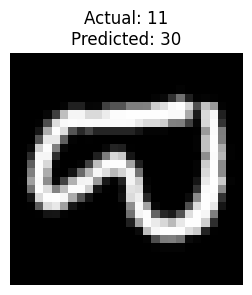

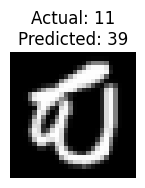

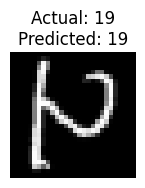

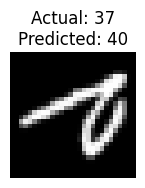

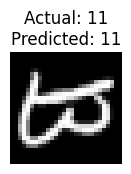

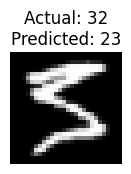

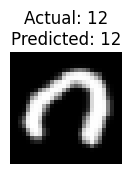

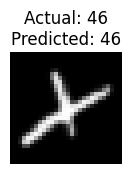

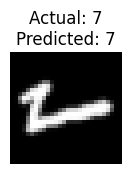

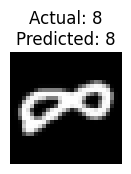

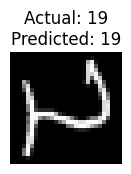

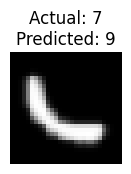

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
filepath='/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv'
df=pd.read_csv(filepath)
print(df.head())
print(df.shape)

algo=int(input("What Algorithm(1.Decision Tree,2.SVM):"))
if algo==1:
    df = df.sample(n=20000, random_state=42)
    y = df.iloc[:, 0]
    X = df.iloc[:, 1:]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    print("Features:",y.shape)
    print("Labels:",X.shape)
    print("Training data:",X_train.shape)
    print("Testing Dara",X_test.shape)
    model=DecisionTreeClassifier(criterion='entropy',max_depth=10,random_state=42)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(accuracy)
    plt.figure(figsize=(12, 8))
    for i in range(12):
        image = X_test.iloc[i].values.reshape(28, 28)
        plt.subplot(3, 4, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"Actual: {y_test.iloc[i]}\n"
            f"Predicted: {y_pred[i]}"
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    df = df.sample(n=20000, random_state=42)
    y = df.iloc[:, 0]
    X = df.iloc[:, 1:]
    X=X/255.0
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    print("Features:",y.shape)
    print("Labels:",X.shape)
    print("Training Data:",X_train.shape)
    print("Testing Data",X_test.shape)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = SVC(kernel='linear', C=1.0, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    y_pred = svm_model.predict(X_test_scaled)

    print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.10f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    labels = np.unique(y)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Reds', values_format='d')
    plt.title("Confusion Matrix")
    plt.show()